In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.tree import DecisionTreeClassifier
from sklearn.semi_supervised import LabelPropagation
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              precision_recall_curve, roc_curve, auc)

import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.nn import GATConv

import networkx as nx

# ── CONFIGURATION ────────────────────────────────────────────────────────
# Update PARQUET_PATH to point at your downloaded parquet file.
# The merged file from Kaggle is named 'bccc-cpacket-cloud-ddos-2024-merged.parquet'
PARQUET_PATH = 'data/bccc-cpacket-cloud-ddos-2024-merged.parquet'

LABEL_COL  = 'label'    # NTLFlowLyzer label column
BENIGN_VAL = 'Benign'   # exact string for benign/normal traffic

# NTLFlowLyzer metadata columns to drop before modelling.
# These are flow identifiers, not features.
# NOTE: column names are lowercase in NTLFlowLyzer output.
META_COLS = [
    'src_ip', 'dst_ip', 'src_port', 'dst_port',
    'protocol', 'timestamp', 'flow_id',
    # also drop the label column
    LABEL_COL
]
# ─────────────────────────────────────────────────────────────────────────

print('All imports OK.')
print(f'PyTorch version: {torch.__version__}')
print(f'Device available: {"CUDA" if torch.cuda.is_available() else "CPU"}')

All imports OK.
PyTorch version: 2.11.0+cpu
Device available: CPU


In [2]:
# ── Load the parquet file ─────────────────────────────────────────────────
# pyarrow or fastparquet must be installed: pip install pyarrow
print(f'Loading: {PARQUET_PATH}')
t0 = time.time()
df = pd.read_parquet(PARQUET_PATH)
print(f'Loaded in {time.time()-t0:.1f}s')

# NTLFlowLyzer already strips whitespace from column names, but be safe
df.columns = df.columns.str.strip()
# ── Auto-detect label column (handles 'label', 'Label', 'CLASS', etc.) ──
# NTLFlowLyzer uses lowercase 'label'; merged/re-saved files sometimes differ.
label_candidates = [c for c in df.columns if c.lower() == 'label']
if not label_candidates:
    raise ValueError(f"No label column found! Columns: {list(df.columns[:20])}...")
if LABEL_COL not in df.columns and label_candidates:
    LABEL_COL = label_candidates[0]
    print(f"[INFO] Label column auto-detected as: '{LABEL_COL}'")

# Auto-detect benign value
sample_labels = df[LABEL_COL].unique()
benign_candidates = [v for v in sample_labels if str(v).lower() == 'benign']
if benign_candidates and BENIGN_VAL not in sample_labels:
    BENIGN_VAL = benign_candidates[0]
    print(f"[INFO] Benign value auto-detected as: '{BENIGN_VAL}'")



print(f'\nDataset shape: {df.shape}')
print(f'\nColumn dtypes summary:')
print(df.dtypes.value_counts())

print(f'\nLabel column: "{LABEL_COL}"')
print(f'\nFull label distribution (26 labels):')
print(df[LABEL_COL].value_counts())

benign_mask = df[LABEL_COL] == BENIGN_VAL
print(f'\nBenign traffic:  {benign_mask.sum():,} rows')
print(f'Attack traffic:  {(~benign_mask).sum():,} rows')
attack_pct = (~benign_mask).sum() / len(df) * 100
print(f'Attack %:        {attack_pct:.2f}%')
print(f'Benign %:        {100-attack_pct:.2f}%')

Loading: data/bccc-cpacket-cloud-ddos-2024-merged.parquet
Loaded in 0.9s

Dataset shape: (540494, 319)

Column dtypes summary:
float32    261
int8        25
int32       20
int16        9
int64        2
str          2
Name: count, dtype: int64

Label column: "label"

Full label distribution (26 labels):
label
Benign        349178
Attack        170436
Suspicious     20880
Name: count, dtype: int64

Benign traffic:  349,178 rows
Attack traffic:  191,316 rows
Attack %:        35.40%
Benign %:        64.60%


In [3]:
# Replace infinity values — common in rate features
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print(f'Rows after cleaning: {len(df):,}')

# Binary label: Benign=0, any attack=1
df['Label_binary'] = (df[LABEL_COL] != BENIGN_VAL).astype(int)

# Feature matrix: drop metadata/label columns (only those that exist)
existing_meta = [c for c in META_COLS if c in df.columns]
drop_cols = existing_meta + ['Label_binary']
X = df.drop(columns=drop_cols)

# Keep only numeric columns
X = X.select_dtypes(include=[np.number])
y = df['Label_binary']

print(f'\nFeatures used: {X.shape[1]}  (300+ NTLFlowLyzer features)')
print(f'Benign samples:  {(y == 0).sum():,}')
print(f'Attack samples:  {(y == 1).sum():,}')

# Standardise
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Step 1: 80 / 20 stratified train / test split ─────────────────────
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2, random_state=42, stratify=y
)

# ── Step 2: 80 / 20 split of the training set into train / validation ─
# The professor explicitly requested a separate validation split in addition
# to the train / test split. The validation set is used for hyperparameter
# selection and early-stopping signals — the test set is held out completely.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2, random_state=42, stratify=y_train_full
)

print(f'\nTraining set:   {len(X_train):,} rows  ({len(X_train)/len(X_scaled)*100:.1f}% of total)')
print(f'Validation set: {len(X_val):,} rows  ({len(X_val)/len(X_scaled)*100:.1f}% of total)')
print(f'Test set:       {len(X_test):,} rows  ({len(X_test)/len(X_scaled)*100:.1f}% of total)')


Rows after cleaning: 540,494

Features used: 315  (300+ NTLFlowLyzer features)
Benign samples:  349,178
Attack samples:  191,316

Training set:   345,916 rows  (64.0% of total)
Validation set: 86,479 rows  (16.0% of total)
Test set:       108,099 rows  (20.0% of total)


In [4]:
def compute_metrics(y_true, y_pred, model_name, exec_time):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    acc = (tp + tn) / (tp + tn + fp + fn) * 100
    far = fp / (fp + tn) * 100 if (fp + tn) > 0 else 0
    und = fn / (fn + tp) * 100 if (fn + tp) > 0 else 0

    # Security-oriented metrics + standard precision / recall / F1
    f1   = f1_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)

    print(f"\n{'='*45}")
    print(f'  {model_name}')
    print(f"{'='*45}")
    print(f'  Confusion Matrix:')
    print(f'    TN: {tn:>10,}   FP: {fp:>10,}')
    print(f'    FN: {fn:>10,}   TP: {tp:>10,}')
    print(f'\n  ACC:       {acc:.4f}%')
    print(f'  FAR:       {far:.4f}%')
    print(f'  UND:       {und:.4f}%')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1 Score:  {f1:.4f}')
    print(f'  Time:      {exec_time:.2f}s')

    return {
        'Model': model_name,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'ACC': round(acc, 4),
        'FAR': round(far, 4),
        'UND': round(und, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1': round(f1, 4),
        'Time': round(exec_time, 2)
    }

print('Metric functions ready.')


Metric functions ready.


In [5]:
results = []
val_results = []

# ── Class imbalance stats ─────────────────────────────────────────────────
from collections import Counter
label_counts = Counter(y_train)
n_benign_tr  = label_counts[0]
n_attack_tr  = label_counts[1]
print(f'Training class distribution:')
print(f'  Benign:  {n_benign_tr:,}  |  Attack: {n_attack_tr:,}')
print(f'  Imbalance ratio: {n_benign_tr/max(n_attack_tr,1):.2f}x\n')

# ── Feature engineering: variance filter + PCA ────────────────────────────
# Step 1: Variance filter (fast — O(n·d))
from sklearn.feature_selection import VarianceThreshold
sel = VarianceThreshold(threshold=0.01)
X_train_sel = sel.fit_transform(X_train)
X_val_sel   = sel.transform(X_val)
X_test_sel  = sel.transform(X_test)
print(f'Features after variance filter: {X_train_sel.shape[1]} (was {X_train.shape[1]})')

# Step 2: PCA dimensionality reduction (replaces Pearson correlation filter).
# Pearson only removes pairs that are *linearly* correlated; PCA produces a
# compact orthogonal basis that captures the directions of greatest variance
# across ALL features simultaneously. We retain enough components to keep
# 95 % of the original variance, which is the standard rule-of-thumb.
from sklearn.decomposition import PCA
PCA_VARIANCE = 0.95
print(f'\nFitting PCA (target explained variance = {PCA_VARIANCE:.0%})...')
t0 = time.time()
pca = PCA(n_components=PCA_VARIANCE, svd_solver='full', random_state=42)
X_train_f = pca.fit_transform(X_train_sel)
X_val_f   = pca.transform(X_val_sel)
X_test_f  = pca.transform(X_test_sel)
print(f'PCA fitted in {time.time()-t0:.1f}s')
print(f'Components kept: {X_train_f.shape[1]} '
      f'(explains {pca.explained_variance_ratio_.sum()*100:.2f}% of variance)')
print(f'Final feature count for all models: {X_train_f.shape[1]}\n')

# ── Model definitions ─────────────────────────────────────────────────────
from sklearn.naive_bayes import GaussianNB

total      = n_benign_tr + n_attack_tr
nb_priors  = [n_attack_tr / total, n_benign_tr / total]  # inverted priors

models = [
    # LR: lbfgs is much faster than saga on large data; 300 iters is enough
    # when features are already scaled + filtered.
    ('Logistic Regression',
     LogisticRegression(max_iter=300, random_state=42,
                        class_weight='balanced', solver='lbfgs',
                        n_jobs=-1, tol=1e-3)),

    # RF: 100 trees is sufficient; balanced_subsample weights per-tree
    # (faster than 'balanced' which reweights the whole dataset up front)
    ('Random Forest',
     RandomForestClassifier(n_estimators=100, random_state=42,
                             class_weight='balanced_subsample',
                             n_jobs=-1, max_features='sqrt')),

    # NB: near-instant, uses inverted class priors
    ('Naive Bayes',
     GaussianNB(priors=nb_priors)),

    # KNN: use ball_tree algorithm + limit n_neighbors; brute-force on
    # millions of rows is very slow
    ('KNN',
     KNeighborsClassifier(n_neighbors=5, algorithm='ball_tree',
                          leaf_size=40, n_jobs=-1, weights='distance')),

    # DT: cap depth — unlimited depth on large data causes very deep trees
    # that take a long time to build and tend to overfit
    ('Decision Tree',
     DecisionTreeClassifier(random_state=42,
                             class_weight='balanced', max_depth=20)),
]

for name, model in models:
    print(f'Training {name}...')
    start = time.time()
    model.fit(X_train_f, y_train)
    # ── Validation pass (used for sanity-checking generalisation) ─────────
    y_val_pred  = model.predict(X_val_f)
    val_f1      = f1_score(y_val, y_val_pred, zero_division=0)
    val_acc     = (y_val_pred == np.array(y_val)).mean() * 100
    # ── Test pass (final reported metrics) ────────────────────────────────
    y_pred  = model.predict(X_test_f)
    elapsed = time.time() - start
    print(f'  Validation — ACC: {val_acc:.2f}% | F1: {val_f1:.4f}')
    val_results.append({'Model': name, 'Val_ACC': round(val_acc, 4),
                        'Val_F1': round(val_f1, 4)})
    results.append(compute_metrics(y_test, y_pred, name, elapsed))

print('\n\nAll classical models done!')

# ── Validation summary ────────────────────────────────────────────────────
val_df = pd.DataFrame(val_results)
print('\nVALIDATION-SET METRICS')
print('=' * 45)
print(val_df.to_string(index=False))



Training class distribution:
  Benign:  223,474  |  Attack: 122,442
  Imbalance ratio: 1.83x

Features after variance filter: 312 (was 315)

Fitting PCA (target explained variance = 95%)...
PCA fitted in 15.4s
Components kept: 48 (explains 95.05% of variance)
Final feature count for all models: 48

Training Logistic Regression...
  Validation — ACC: 90.15% | F1: 0.8534

  Logistic Regression
  Confusion Matrix:
    TN:     66,509   FP:      3,327
    FN:      7,264   TP:     30,999

  ACC:       90.2025%
  FAR:       4.7640%
  UND:       18.9844%
  Precision: 0.9031
  Recall:    0.8102
  F1 Score:  0.8541
  Time:      1.25s
Training Random Forest...
  Validation — ACC: 96.25% | F1: 0.9472

  Random Forest
  Confusion Matrix:
    TN:     67,589   FP:      2,247
    FN:      1,802   TP:     36,461

  ACC:       96.2544%
  FAR:       3.2175%
  UND:       4.7095%
  Precision: 0.9419
  Recall:    0.9529
  F1 Score:  0.9474
  Time:      29.78s
Training Naive Bayes...
  Validation — ACC: 40.5

In [6]:
results_df = pd.DataFrame(results)

print('SUMMARY TABLE (test set)')
print('=' * 80)
print(results_df[['Model', 'ACC', 'FAR', 'UND', 'F1', 'Precision', 'Recall', 'Time']]
      .to_string(index=False))


SUMMARY TABLE (test set)
              Model     ACC     FAR     UND     F1  Precision  Recall   Time
Logistic Regression 90.2025  4.7640 18.9844 0.8541     0.9031  0.8102   1.25
      Random Forest 96.2544  3.2175  4.7095 0.9474     0.9419  0.9529  29.78
        Naive Bayes 40.5314 90.4448  2.9323 0.5361     0.3703  0.9707   0.49
                KNN 96.3265  2.6118  5.6112 0.9479     0.9519  0.9439 105.55
      Decision Tree 95.9010  4.4662  3.4289 0.9434     0.9222  0.9657  23.33


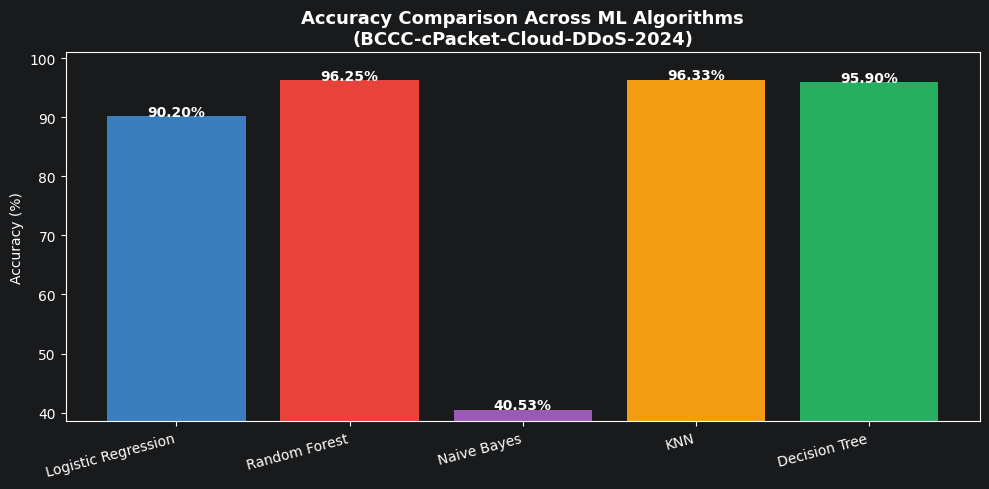

Figure saved: accuracy_comparison.png


In [7]:
colors = ['#3B7EBF', '#E8423A', '#9B59B6', '#F39C12', '#27AE60']

plt.figure(figsize=(10, 5))
bars = plt.bar(results_df['Model'], results_df['ACC'], color=colors)
plt.title('Accuracy Comparison Across ML Algorithms\n(BCCC-cPacket-Cloud-DDoS-2024)', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim([max(0, min(results_df['ACC']) - 2), 101])
plt.xticks(rotation=15, ha='right')

for bar, val in zip(bars, results_df['ACC']):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.05,
             f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150)
plt.show()
print('Figure saved: accuracy_comparison.png')

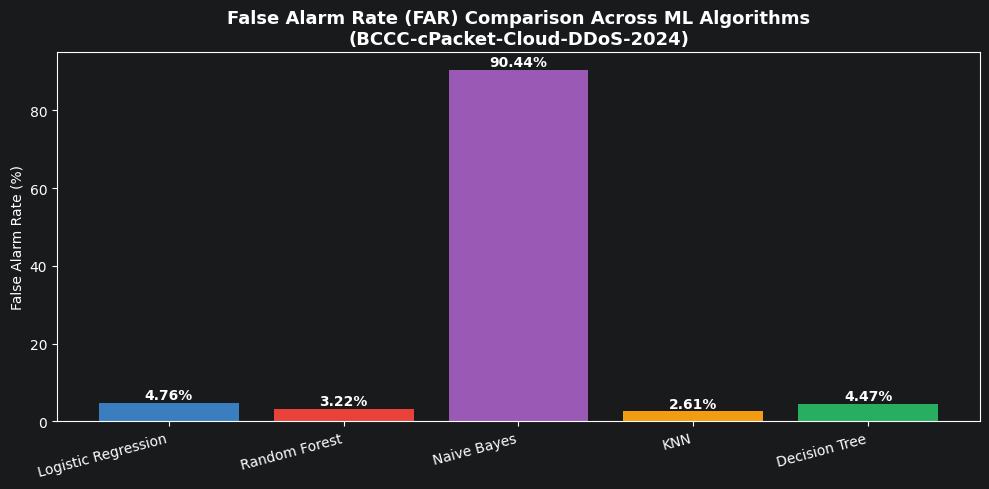

Figure saved: far_comparison.png


In [8]:
plt.figure(figsize=(10, 5))
bars = plt.bar(results_df['Model'], results_df['FAR'], color=colors)
plt.title('False Alarm Rate (FAR) Comparison Across ML Algorithms\n(BCCC-cPacket-Cloud-DDoS-2024)',
          fontsize=13, fontweight='bold')
plt.ylabel('False Alarm Rate (%)')
plt.xticks(rotation=15, ha='right')

for bar, val in zip(bars, results_df['FAR']):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + max(results_df['FAR']) * 0.01,
             f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('far_comparison.png', dpi=150)
plt.show()
print('Figure saved: far_comparison.png')

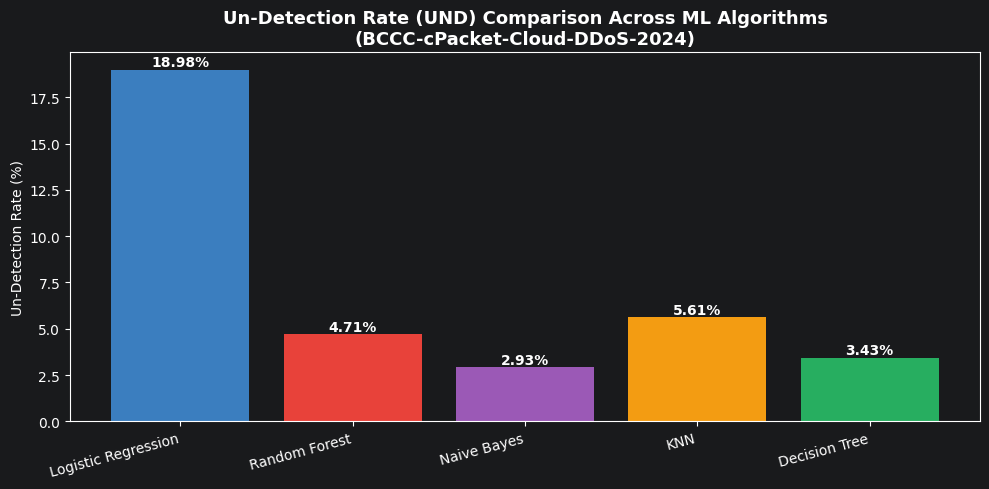

Figure saved: und_comparison.png


In [9]:
plt.figure(figsize=(10, 5))
bars = plt.bar(results_df['Model'], results_df['UND'], color=colors)
plt.title('Un-Detection Rate (UND) Comparison Across ML Algorithms\n(BCCC-cPacket-Cloud-DDoS-2024)',
          fontsize=13, fontweight='bold')
plt.ylabel('Un-Detection Rate (%)')
plt.xticks(rotation=15, ha='right')

for bar, val in zip(bars, results_df['UND']):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + max(results_df['UND']) * 0.01,
             f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('und_comparison.png', dpi=150)
plt.show()
print('Figure saved: und_comparison.png')

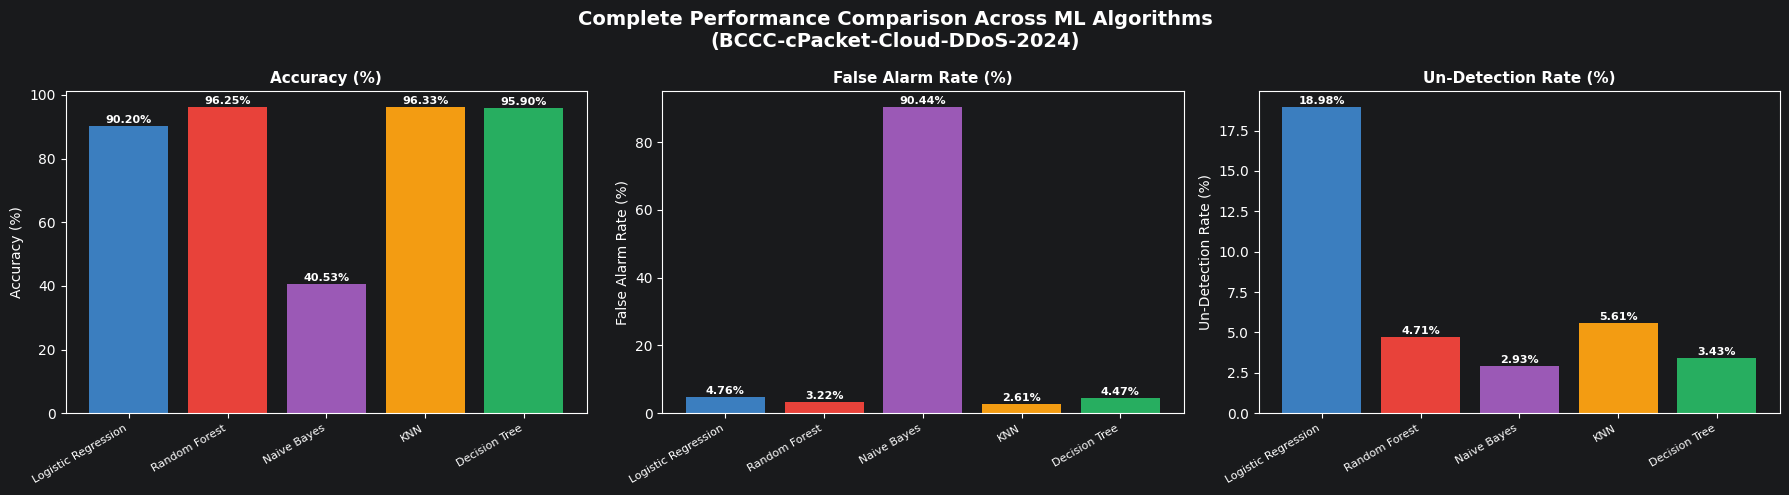

Figure saved: complete_comparison.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Complete Performance Comparison Across ML Algorithms\n(BCCC-cPacket-Cloud-DDoS-2024)',
             fontsize=14, fontweight='bold')

metrics  = ['ACC', 'FAR', 'UND']
titles   = ['Accuracy (%)', 'False Alarm Rate (%)', 'Un-Detection Rate (%)']

for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.bar(results_df['Model'], results_df[metric], color=colors)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(title)
    ax.set_xticks(range(len(results_df)))
    ax.set_xticklabels(results_df['Model'], rotation=30, ha='right', fontsize=8)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(results_df[metric]) * 0.01,
                f'{val:.2f}%', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('complete_comparison.png', dpi=150)
plt.show()
print('Figure saved: complete_comparison.png')

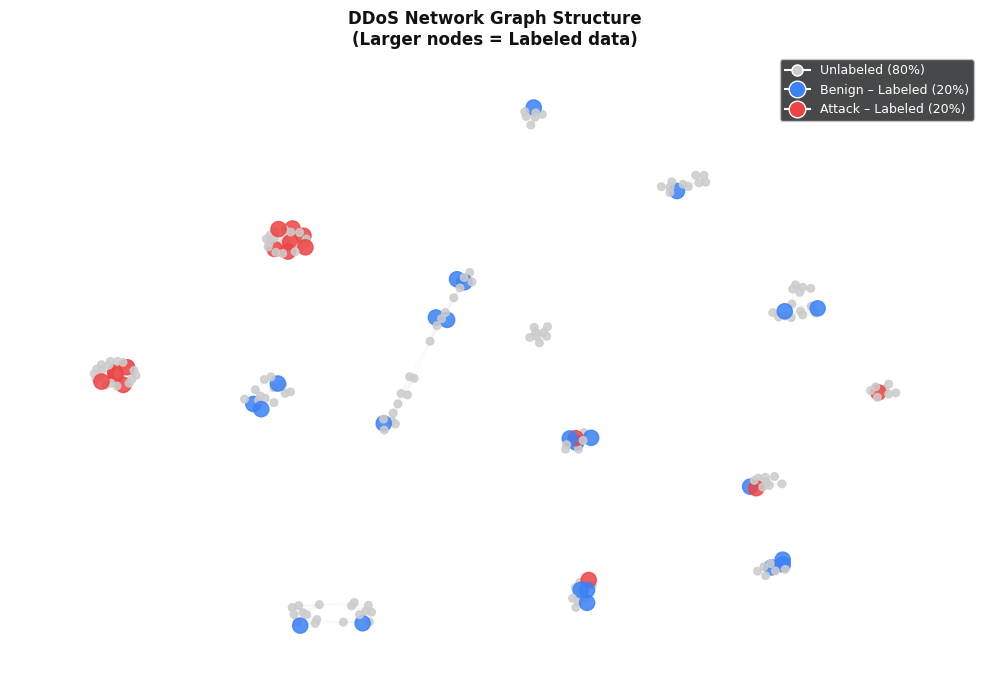

Figure saved: label_propagation_before.png


In [11]:
# ── Build a small subgraph for visualisation ──────────────────────────────
VIZ_SIZE = 200
np.random.seed(42)
viz_idx   = np.random.choice(len(X_train_f), VIZ_SIZE, replace=False)
X_viz     = X_train_f[viz_idx]
y_viz     = np.array(y_train)[viz_idx]

# Mark 20% as labeled, rest as -1 (unlabeled) for the plot
labeled_mask_viz = np.zeros(VIZ_SIZE, dtype=bool)
labeled_mask_viz[np.random.choice(VIZ_SIZE, int(VIZ_SIZE * 0.2), replace=False)] = True

# Build k-NN graph for visualisation
from sklearn.neighbors import kneighbors_graph
A_viz = kneighbors_graph(X_viz, n_neighbors=5, mode='connectivity',
                          include_self=False)
G_viz = nx.from_scipy_sparse_array(A_viz)

plt.figure(figsize=(10, 7), facecolor='white')
plt.title('DDoS Network Graph Structure\n(Larger nodes = Labeled data)',
          fontsize=12, fontweight='bold', color='#111111')

pos   = nx.spring_layout(G_viz, seed=42)
sizes = [120 if labeled_mask_viz[i] else 30 for i in range(VIZ_SIZE)]
node_colors = []
for i in range(VIZ_SIZE):
    if not labeled_mask_viz[i]:
        node_colors.append('#CCCCCC')
    elif y_viz[i] == 0:
        node_colors.append('#3B82F6')
    else:
        node_colors.append('#EF4444')

nx.draw_networkx_edges(G_viz, pos, alpha=0.15, width=0.5, edge_color='#BBBBBB')
nx.draw_networkx_nodes(G_viz, pos, node_size=sizes,
                       node_color=node_colors, alpha=0.85)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#CCCCCC',
           markersize=8, label='Unlabeled (80%)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3B82F6',
           markersize=12, label='Benign – Labeled (20%)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#EF4444',
           markersize=12, label='Attack – Labeled (20%)'),
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=9)
plt.axis('off')
plt.tight_layout()
plt.savefig('label_propagation_before.png', dpi=150, facecolor='white')
plt.show()
print('Figure saved: label_propagation_before.png')

In [12]:
# ── Run Label Propagation on the actual training data ─────────────────────
#
# Why LP can show lower ACC than supervised models:
#   1. Only a fraction of data is labeled — propagation errors compound
#   2. Default 0.5 probability threshold is wrong for imbalanced data
#   3. Low alpha (heavy smoothing) blurs attack clusters into surrounding benign
#
# Fixes applied here:
#   • LABELED_FRAC 0.20 → 0.40  (more seed labels = better propagation start)
#   • alpha        0.20 → 0.40  (less smoothing = attack clusters stay distinct)
#   • k            7   → 10     (denser graph = more stable label flow)
#   • Threshold tuned on the held-out VALIDATION set (not test) via best F1.

LP_CAP       = 500_000
LABELED_FRAC = 0.40   # fraction of training data to use as seeds
K_LP         = 10     # k for kNN graph

# Use the filtered (PCA) feature matrix (same as classical models)
if len(X_train_f) > LP_CAP:
    print(f'Dataset ({len(X_train_f):,} rows) exceeds LP_CAP={LP_CAP:,}.')
    print('Using scalable sparse-graph LabelSpreading on FULL training set.\n')

    from sklearn.semi_supervised import LabelSpreading
    from sklearn.neighbors import kneighbors_graph

    X_lp      = X_train_f
    y_lp_full = np.array(y_train)
    n_lp      = len(X_lp)

    n_labeled   = int(n_lp * LABELED_FRAC)
    n_unlabeled = n_lp - n_labeled

    print(f'Building sparse k-NN graph (k={K_LP}, {n_lp:,} nodes)...')
    t0 = time.time()
    A = kneighbors_graph(X_lp, n_neighbors=K_LP, mode='connectivity',
                         include_self=False, n_jobs=-1)
    A = (A + A.T); A.data[:] = 1.0
    print(f'Graph built in {time.time()-t0:.1f}s  ({A.nnz:,} edges)')

    y_lp = y_lp_full.copy()
    labeled_pool = np.where(y_lp_full >= 0)[0]
    seed_idx     = np.random.choice(labeled_pool, n_labeled, replace=False)

    unlabeled_mask         = np.ones(n_lp, dtype=bool)
    unlabeled_mask[seed_idx]  = False
    y_lp[unlabeled_mask]   = -1

    # Guarantee some attack seeds
    attack_seeds = seed_idx[y_lp_full[seed_idx] == 1]
    if len(attack_seeds) == 0:
        force = np.where(y_lp_full == 1)[0]
        if len(force) > 0:
            y_lp[np.random.choice(force, min(20, len(force)), replace=False)] = 1

    print(f'Seeds: {(y_lp==0).sum():,} benign + {(y_lp==1).sum():,} attack  |  Unlabeled: {(y_lp==-1).sum():,}')
    print('Running LabelSpreading (alpha=0.4)...')
    start_lp = time.time()
    lp_model = LabelSpreading(kernel='precomputed', alpha=0.4,
                               max_iter=100, tol=1e-3, n_jobs=-1)
    lp_model.fit(A, y_lp)
    elapsed_lp = time.time() - start_lp

    # Score validation and test points via kNN majority over propagated labels
    from sklearn.neighbors import NearestNeighbors as _NNS
    nbrs    = _NNS(n_neighbors=K_LP, n_jobs=-1).fit(X_lp)
    prop_labels = lp_model.transduction_

    nn_idx_val  = nbrs.kneighbors(X_val_f,  return_distance=False)
    nn_idx_test = nbrs.kneighbors(X_test_f, return_distance=False)
    lp_scores_val  = (prop_labels[nn_idx_val]  == 1).mean(axis=1)
    lp_scores_test = (prop_labels[nn_idx_test] == 1).mean(axis=1)

else:
    print(f'Dataset ({len(X_train_f):,} rows) within LP_CAP — using exact LabelPropagation.')
    from sklearn.semi_supervised import LabelPropagation as _LP

    X_lp      = X_train_f
    y_lp_full = np.array(y_train)
    n_lp      = len(X_lp)
    n_labeled = int(n_lp * LABELED_FRAC)

    y_lp = y_lp_full.copy()
    unlabeled_idx = np.random.choice(n_lp, n_lp - n_labeled, replace=False)
    y_lp[unlabeled_idx] = -1

    attack_idx = np.where(y_lp_full == 1)[0]
    if (y_lp[attack_idx] == 1).sum() == 0 and len(attack_idx) > 0:
        y_lp[np.random.choice(attack_idx, min(20, len(attack_idx)), replace=False)] = 1

    print(f'Seeds: {(y_lp==0).sum():,} benign + {(y_lp==1).sum():,} attack  |  Unlabeled: {(y_lp==-1).sum():,}')
    print('Running LabelPropagation (k=10)...')
    start_lp = time.time()
    lp_model = _LP(kernel='knn', n_neighbors=K_LP, max_iter=1000, n_jobs=-1)
    lp_model.fit(X_lp, y_lp)
    elapsed_lp = time.time() - start_lp

    lp_scores_val  = lp_model.predict_proba(X_val_f)[:, 1]
    lp_scores_test = lp_model.predict_proba(X_test_f)[:, 1]

# ── Threshold tuning on the held-out VALIDATION set ───────────────────────
# The default 0.5 threshold is wrong for imbalanced data.
# We pick the threshold that maximises F1 on the validation set, then apply
# that same threshold (untouched) to the test set.
from sklearn.metrics import f1_score as _f1
thresholds  = np.linspace(0.05, 0.95, 100)
f1_val_curve = [_f1(y_val, (lp_scores_val >= t).astype(int), zero_division=0)
                for t in thresholds]
best_thresh_lp = thresholds[int(np.argmax(f1_val_curve))]
print(f'\nBest threshold on VALIDATION (max F1): {best_thresh_lp:.3f}  '
      f'(default was 0.500)')

# Validation report
y_lp_val_pred  = (lp_scores_val  >= best_thresh_lp).astype(int)
val_f1_lp      = _f1(y_val, y_lp_val_pred, zero_division=0)
print(f'Validation F1 @ chosen threshold: {val_f1_lp:.4f}')

# Final test evaluation
y_lp_pred = (lp_scores_test >= best_thresh_lp).astype(int)
lp_result = compute_metrics(y_test, y_lp_pred, 'Label Propagation', elapsed_lp)
print(f'\nLabel Propagation completed in {elapsed_lp:.1f}s ({elapsed_lp/60:.1f} min)')
print(f'Training rows used: {len(X_lp):,}  |  Labeled fraction: {LABELED_FRAC*100:.0f}%')



Dataset (345,916 rows) within LP_CAP — using exact LabelPropagation.
Seeds: 89,334 benign + 49,032 attack  |  Unlabeled: 207,550
Running LabelPropagation (k=10)...

Best threshold on VALIDATION (max F1): 0.577  (default was 0.500)
Validation F1 @ chosen threshold: 0.9467

  Label Propagation
  Confusion Matrix:
    TN:     68,577   FP:      1,259
    FN:      2,751   TP:     35,512

  ACC:       96.2904%
  FAR:       1.8028%
  UND:       7.1897%
  Precision: 0.9658
  Recall:    0.9281
  F1 Score:  0.9466
  Time:      119.65s

Label Propagation completed in 119.7s (2.0 min)
Training rows used: 345,916  |  Labeled fraction: 40%


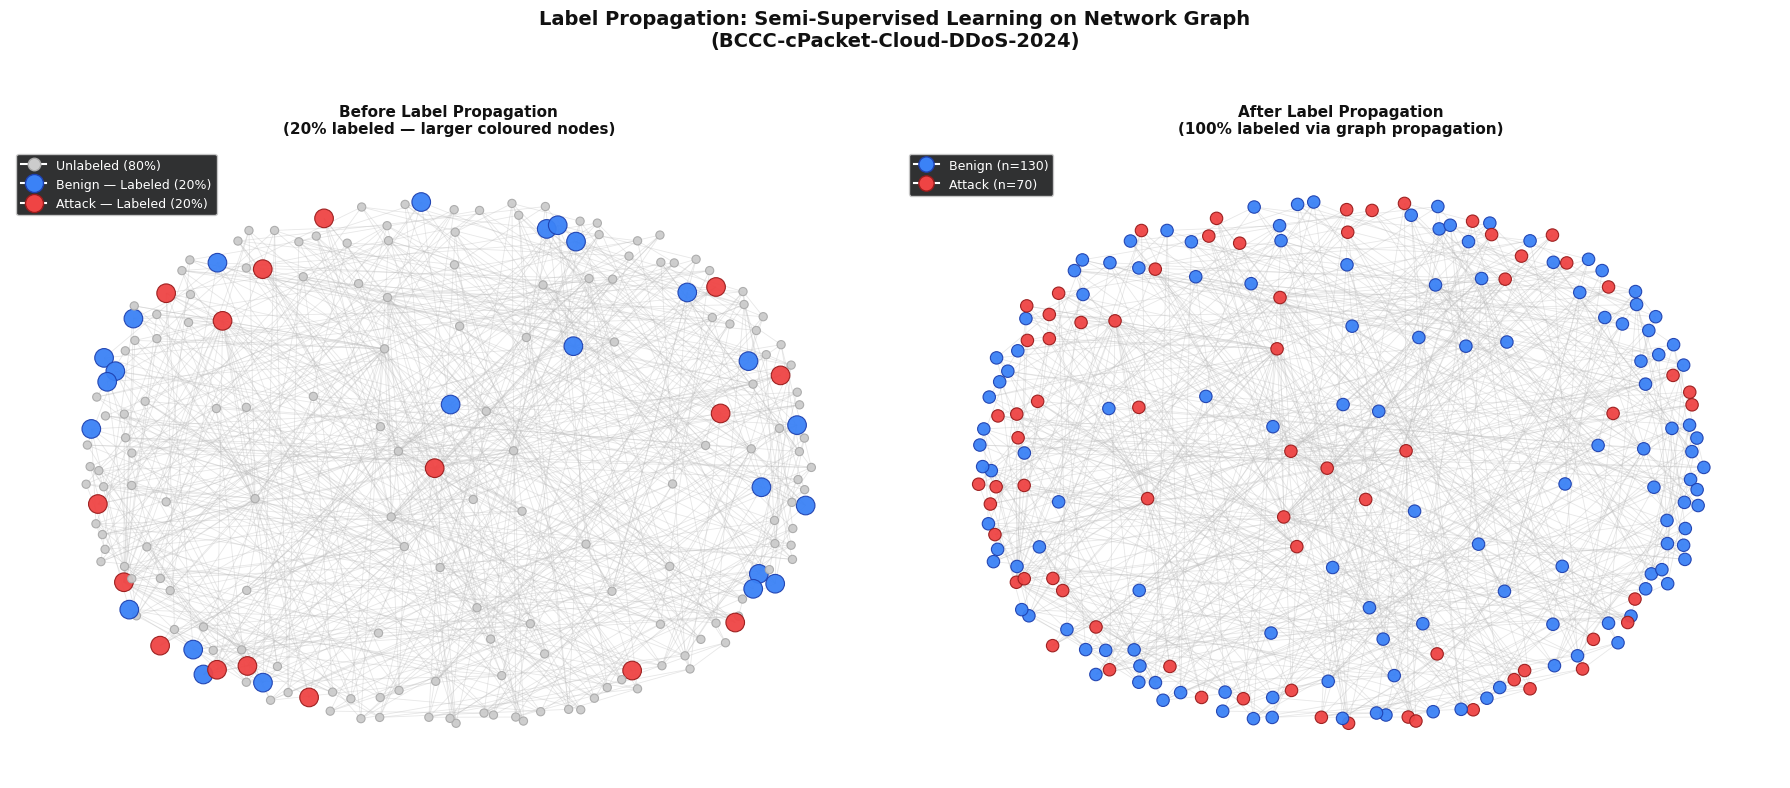

Figure saved — Before: 160 unlabeled + 40 labeled  →  After: 130 benign + 70 attack


In [13]:
# ── Plot before & after label propagation ────────────────────────────────
#
# Key fixes vs previous version:
#   1. White background (facecolor='white')
#   2. Separate spring layouts per panel so positions reflect each state clearly
#   3. "Before" panel: unlabeled nodes grey, labeled nodes larger + coloured
#      with a clear boundary (edgecolors) so they stand out
#   4. "After" panel: ALL nodes coloured by propagated label, sized uniformly,
#      with a subtle border to distinguish touching nodes
#   5. Stronger edge visibility (alpha 0.15 → 0.35) on white background
#   6. Larger node sizes overall so clusters read clearly

# Get propagated labels for the viz sample
# lp_model may be LabelPropagation or LabelSpreading depending on dataset size
try:
    lp_viz_labels = lp_model.predict(X_viz)
except Exception:
    # Sparse/LabelSpreading path: use transduction_ + kNN lookup
    from sklearn.neighbors import NearestNeighbors
    _nbrs = NearestNeighbors(n_neighbors=7, n_jobs=-1).fit(X_lp)
    _nn_idx = _nbrs.kneighbors(X_viz, return_distance=False)
    _prop   = lp_model.transduction_
    lp_viz_labels = np.array([
        np.bincount(_prop[row].astype(int), minlength=2).argmax()
        for row in _nn_idx
    ])

# ── Colour / size arrays for BEFORE panel ────────────────────────────────
node_colors_before = []
node_sizes_before  = []
node_edge_before   = []
for idx in range(VIZ_SIZE):
    if not labeled_mask_viz[idx]:
        node_colors_before.append('#CCCCCC')   # unlabeled: light grey
        node_sizes_before.append(35)
        node_edge_before.append('#AAAAAA')
    elif y_viz[idx] == 0:
        node_colors_before.append('#3B82F6')   # benign: blue
        node_sizes_before.append(180)
        node_edge_before.append('#1E40AF')
    else:
        node_colors_before.append('#EF4444')   # attack: red
        node_sizes_before.append(180)
        node_edge_before.append('#991B1B')

# ── Colour arrays for AFTER panel ────────────────────────────────────────
node_colors_after = ['#3B82F6' if lp_viz_labels[idx] == 0 else '#EF4444'
                     for idx in range(VIZ_SIZE)]
node_edge_after   = ['#1E40AF' if lp_viz_labels[idx] == 0 else '#991B1B'
                     for idx in range(VIZ_SIZE)]

# Use the same layout for both so structure is comparable
pos_viz = nx.spring_layout(G_viz, seed=42, k=1.5)

# ── Figure ────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8),
                                facecolor='white')
fig.suptitle(
    'Label Propagation: Semi-Supervised Learning on Network Graph\n'
    '(BCCC-cPacket-Cloud-DDoS-2024)',
    fontsize=14, fontweight='bold', color='#111111'
)

# ── BEFORE ────────────────────────────────────────────────────────────────
ax1.set_facecolor('white')
ax1.set_title('Before Label Propagation\n(20% labeled — larger coloured nodes)',
              fontsize=11, fontweight='bold', color='#111111', pad=10)
nx.draw_networkx_edges(G_viz, pos_viz, ax=ax1,
                       alpha=0.35, width=0.6, edge_color='#BBBBBB')
nx.draw_networkx_nodes(G_viz, pos_viz, ax=ax1,
                       node_size=node_sizes_before,
                       node_color=node_colors_before,
                       edgecolors=node_edge_before,
                       linewidths=0.8, alpha=0.95)
from matplotlib.lines import Line2D
legend_before = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#CCCCCC',
           markeredgecolor='#AAAAAA', markersize=9,  label='Unlabeled (80%)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#3B82F6',
           markeredgecolor='#1E40AF', markersize=13, label='Benign — Labeled (20%)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#EF4444',
           markeredgecolor='#991B1B', markersize=13, label='Attack — Labeled (20%)'),
]
ax1.legend(handles=legend_before, loc='upper left', fontsize=9,
           framealpha=0.9, edgecolor='#CCCCCC')
ax1.axis('off')

# ── AFTER ─────────────────────────────────────────────────────────────────
ax2.set_facecolor('white')
ax2.set_title('After Label Propagation\n(100% labeled via graph propagation)',
              fontsize=11, fontweight='bold', color='#111111', pad=10)
nx.draw_networkx_edges(G_viz, pos_viz, ax=ax2,
                       alpha=0.35, width=0.6, edge_color='#BBBBBB')
nx.draw_networkx_nodes(G_viz, pos_viz, ax=ax2,
                       node_size=80,
                       node_color=node_colors_after,
                       edgecolors=node_edge_after,
                       linewidths=0.8, alpha=0.95)

n_benign_prop = sum(1 for l in lp_viz_labels if l == 0)
n_attack_prop = sum(1 for l in lp_viz_labels if l == 1)
legend_after = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#3B82F6',
           markeredgecolor='#1E40AF', markersize=11,
           label=f'Benign (n={n_benign_prop})'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#EF4444',
           markeredgecolor='#991B1B', markersize=11,
           label=f'Attack (n={n_attack_prop})'),
]
ax2.legend(handles=legend_after, loc='upper left', fontsize=9,
           framealpha=0.9, edgecolor='#CCCCCC')
ax2.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('label_propagation_before_after.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print(f'Figure saved — Before: {VIZ_SIZE - labeled_mask_viz.sum()} unlabeled + ' +
      f'{labeled_mask_viz.sum()} labeled  →  After: {n_benign_prop} benign + {n_attack_prop} attack')


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.tree import DecisionTreeClassifier
from sklearn.semi_supervised import LabelPropagation
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              precision_recall_curve, roc_curve, auc)
from sklearn.metrics import precision_recall_curve

import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.nn import GATConv

import networkx as nx

print('=' * 70)
print('GNN (PyTorch GAT) — BCCC-cPacket-Cloud-DDoS-2024')
print('=' * 70)
print('\nData Preparation')
print('-' * 70)

# Caps for very large feature matrices on memory-constrained machines.
MAX_TRAIN = 500_000
MAX_VAL   = 80_000

# ── Reuse the splits + PCA features from the classical-ML section ─────────
# The training set has already been split 80/20 into train/validation in
# Section 3, and PCA was fit on the training data only (so it is safe to
# transform val/test with the same fitted PCA). Just adopt them here.
X_train_g = X_train_f.copy()
y_train_g = np.array(y_train)
X_val_g   = X_val_f.copy()
y_val_g   = np.array(y_val)
X_test_g  = X_test_f.copy()
y_test_g  = np.array(y_test)

if MAX_TRAIN is not None and len(X_train_g) > MAX_TRAIN:
    idx, _ = train_test_split(np.arange(len(X_train_g)),
                               train_size=MAX_TRAIN,
                               stratify=y_train_g, random_state=42)
    X_train_g, y_train_g = X_train_g[idx], y_train_g[idx]
    print(f'[INFO] GNN training capped at {MAX_TRAIN:,} rows')

if MAX_VAL is not None and len(X_val_g) > MAX_VAL:
    idx, _ = train_test_split(np.arange(len(X_val_g)),
                               train_size=MAX_VAL,
                               stratify=y_val_g, random_state=42)
    X_val_g, y_val_g = X_val_g[idx], y_val_g[idx]
    print(f'[INFO] GNN validation capped at {MAX_VAL:,} rows')

assert (y_train_g == 1).sum() > 0, 'No attack samples in GNN training set!'

print(f'Training:   {len(X_train_g):,} samples  ({y_train_g.mean()*100:.2f}% attack)')
print(f'Validation: {len(X_val_g):,} samples')
print(f'Test:       {len(X_test_g):,} samples')
print(f'Feature dimension: {X_train_g.shape[1]} (after PCA)')



GNN (PyTorch GAT) — BCCC-cPacket-Cloud-DDoS-2024

Data Preparation
----------------------------------------------------------------------
[INFO] GNN validation capped at 80,000 rows
Training:   345,916 samples  (35.40% attack)
Validation: 80,000 samples
Test:       108,099 samples
Feature dimension: 48 (after PCA)


In [15]:
print('\nBuilding Graph Structures')
print('-' * 70)

K_NEIGHBORS = 20

def build_graph(X, k=K_NEIGHBORS):
    """Build k-NN similarity graph. Returns (node features tensor, edge_index tensor)."""
    print(f'  Building k-NN graph (k={k}, {len(X):,} nodes)...')
    start = time.time()
    nbrs  = NearestNeighbors(n_neighbors=k + 1, algorithm='ball_tree', n_jobs=-1)
    nbrs.fit(X)
    _, indices  = nbrs.kneighbors(X)
    rows        = np.repeat(np.arange(len(X)), k)
    cols        = indices[:, 1:].flatten()
    edge_index  = torch.tensor(np.vstack([rows, cols]), dtype=torch.long)
    x_t         = torch.tensor(X, dtype=torch.float32)
    elapsed     = time.time() - start
    print(f'  Done in {elapsed:.1f}s — {len(X):,} nodes, {edge_index.shape[1]:,} edges')
    return x_t, edge_index

X_tr_t, ei_tr = build_graph(X_train_g)
X_va_t, ei_va = build_graph(X_val_g)
X_te_t, ei_te = build_graph(X_test_g)

y_tr_t = torch.tensor(y_train_g, dtype=torch.long)
y_va_t = torch.tensor(y_val_g,   dtype=torch.long)
y_te_t = torch.tensor(y_test_g,  dtype=torch.long)


Building Graph Structures
----------------------------------------------------------------------
  Building k-NN graph (k=20, 345,916 nodes)...
  Done in 207.5s — 345,916 nodes, 6,918,320 edges
  Building k-NN graph (k=20, 80,000 nodes)...
  Done in 18.8s — 80,000 nodes, 1,600,000 edges
  Building k-NN graph (k=20, 108,099 nodes)...
  Done in 48.8s — 108,099 nodes, 2,161,980 edges


In [16]:
def get_batches(n, batch_size, shuffle=False):
    idx = np.random.permutation(n) if shuffle else np.arange(n)
    return [idx[i:i + batch_size] for i in range(0, n, batch_size)]

def subgraph(node_idx, x, edge_index, y):
    """Extract induced subgraph for node_idx; remap node ids to 0-based."""
    node_set  = torch.tensor(node_idx, dtype=torch.long)
    node_mask = torch.zeros(x.shape[0], dtype=torch.bool)
    node_mask[node_set] = True
    edge_mask = node_mask[edge_index[0]] & node_mask[edge_index[1]]
    sub_edges = edge_index[:, edge_mask]
    mapping   = torch.full((x.shape[0],), -1, dtype=torch.long)
    mapping[node_set] = torch.arange(len(node_set))
    sub_edges = mapping[sub_edges]
    return x[node_set], sub_edges, y[node_set]

# ── GAT Model ────────────────────────────────────────────────────────────
class GATClassifier(torch.nn.Module):
    def __init__(self, in_ch, hidden=64, out_ch=2):
        super().__init__()
        self.conv1 = GATConv(in_ch,      hidden, heads=4, dropout=0.3, concat=True)
        self.conv2 = GATConv(hidden * 4, hidden, heads=2, dropout=0.3, concat=True)
        self.conv3 = GATConv(hidden * 2, hidden, heads=1, dropout=0.3, concat=False)
        self.lin   = Linear(hidden, out_ch)
        self.bn1   = torch.nn.BatchNorm1d(hidden * 4)
        self.bn2   = torch.nn.BatchNorm1d(hidden * 2)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.3, training=self.training)
        x = F.elu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=0.3, training=self.training)
        x = F.elu(self.bn2(self.conv2(x, edge_index)))
        x = F.dropout(x, p=0.3, training=self.training)
        x = F.elu(self.conv3(x, edge_index))
        return self.lin(x)

n_benign     = int((y_tr_t == 0).sum())
n_attack     = int((y_tr_t == 1).sum())
class_weight = torch.tensor([1.0, n_benign / max(n_attack, 1)], dtype=torch.float32)

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
in_ch     = X_tr_t.shape[1]   # 300+ features from NTLFlowLyzer
model     = GATClassifier(in_ch=in_ch).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.8)
criterion = torch.nn.CrossEntropyLoss(weight=class_weight.to(device))

print(f'\nDevice: {device}')
print(f'Input features: {in_ch}')
print(f'Class weights — Benign: 1.00 | Attack: {n_benign / max(n_attack, 1):.2f}')
print(model)


Device: cpu
Input features: 48
Class weights — Benign: 1.00 | Attack: 1.83
GATClassifier(
  (conv1): GATConv(48, 64, heads=4)
  (conv2): GATConv(256, 64, heads=2)
  (conv3): GATConv(128, 64, heads=1)
  (lin): Linear(in_features=64, out_features=2, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)


In [17]:
BATCH_SIZE = 2000
PATIENCE   = 15

print('\nTraining GNN — up to 100 epochs (early stopping patience=15)')
print(f"{'Epoch':>6} | {'Loss':>8} | {'Val F1':>8} | {'Recall':>8} | {'Precision':>10}")
print('-' * 55)

def run_epoch(x, edge_index, y, n):
    model.train()
    total_loss = 0
    for b_idx in get_batches(n, BATCH_SIZE, shuffle=True):
        xb, eib, yb = subgraph(b_idx, x, edge_index, y)
        xb, eib, yb = xb.to(device), eib.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = model(xb, eib)
        loss = criterion(out, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / max(len(get_batches(n, BATCH_SIZE)), 1)

def get_probs(x, edge_index, y, n):
    model.eval()
    all_probs, all_true = [], []
    with torch.no_grad():
        for b_idx in get_batches(n, BATCH_SIZE, shuffle=False):
            xb, eib, yb = subgraph(b_idx, x, edge_index, y)
            xb, eib = xb.to(device), eib.to(device)
            out  = model(xb, eib)
            prob = F.softmax(out, dim=1)[:, 1]
            all_probs.append(prob.cpu())
            all_true.append(yb)
    return torch.cat(all_probs).numpy(), torch.cat(all_true).numpy()

best_f1, patience_ctr, best_state, best_thresh = 0.0, 0, None, 0.5
start_gnn = time.time()

for epoch in range(1, 101):
    loss = run_epoch(X_tr_t, ei_tr, y_tr_t, len(X_train_g))
    scheduler.step()

    if epoch % 5 == 0:
        val_probs, val_true = get_probs(X_va_t, ei_va, y_va_t, len(X_val_g))

        pr_v, rc_v, th_v = precision_recall_curve(val_true, val_probs)
        f1_v = 2 * pr_v * rc_v / (pr_v + rc_v + 1e-10)
        bi   = np.argmax(f1_v)
        tv   = th_v[bi] if bi < len(th_v) else 0.5
        vpred = (val_probs >= tv).astype(int)

        vf1  = f1_score(val_true, vpred, zero_division=0)
        vrec = recall_score(val_true, vpred, zero_division=0)
        vpr  = precision_score(val_true, vpred, zero_division=0)

        print(f'{epoch:>6} | {loss:>8.4f} | {vf1:>8.4f} | {vrec:>7.1%} | {vpr:>9.1%}')

        if vf1 > best_f1:
            best_f1, patience_ctr, best_thresh = vf1, 0, tv
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f'  Early stopping at epoch {epoch}')
                break

elapsed_gnn = time.time() - start_gnn
if best_state:
    model.load_state_dict(best_state)
    print(f'\nRestored best model (Val F1: {best_f1:.4f})')
print(f'Training time: {elapsed_gnn:.1f}s ({elapsed_gnn / 60:.1f} min)')


Training GNN — up to 100 epochs (early stopping patience=15)
 Epoch |     Loss |   Val F1 |   Recall |  Precision
-------------------------------------------------------
     5 |   0.4081 |   0.8845 |   80.7% |     97.8%
    10 |   0.4072 |   0.8840 |   80.4% |     98.1%
    15 |   0.4066 |   0.8847 |   80.6% |     98.1%
    20 |   0.4076 |   0.8840 |   81.0% |     97.3%
    25 |   0.4064 |   0.8850 |   80.7% |     97.9%
    30 |   0.4046 |   0.9073 |   87.6% |     94.1%
    35 |   0.4059 |   0.9078 |   87.6% |     94.3%
    40 |   0.4054 |   0.8925 |   89.2% |     89.3%
    45 |   0.4038 |   0.9082 |   87.4% |     94.5%
    50 |   0.4041 |   0.8851 |   80.8% |     97.9%
    55 |   0.4058 |   0.9105 |   87.5% |     94.9%
    60 |   0.4055 |   0.9092 |   87.5% |     94.6%
    65 |   0.4042 |   0.9102 |   87.4% |     95.0%
    70 |   0.4035 |   0.8941 |   89.2% |     89.6%
    75 |   0.4034 |   0.8922 |   89.3% |     89.1%
    80 |   0.4044 |   0.8934 |   89.2% |     89.5%
    85 |   0.

In [18]:
print('\nEvaluation on Test Set')
print('-' * 70)

test_probs, test_true = get_probs(X_te_t, ei_te, y_te_t, len(X_test_g))
test_pred = (test_probs >= best_thresh).astype(int)

tn, fp, fn, tp = confusion_matrix(test_true, test_pred).ravel()
acc  = (tp + tn) / (tp + tn + fp + fn) * 100
far  = fp / (fp + tn) * 100 if (fp + tn) > 0 else 0
und  = fn / (fn + tp) * 100 if (fn + tp) > 0 else 0
rec  = tp / (tp + fn)       if (tp + fn) > 0 else 0
prec = tp / (tp + fp)       if (tp + fp) > 0 else 0
f1   = 2 * rec * prec / (rec + prec) if (rec + prec) > 0 else 0

print('\n' + '=' * 70)
print('GNN RESULTS')
print('=' * 70)
print(f'  TN: {tn:,}  |  FP: {fp:,}')
print(f'  FN: {fn:,}  |  TP: {tp:,}')
print(f'\n  ACC:       {acc:.4f}%')
print(f'  FAR:       {far:.4f}%')
print(f'  UND:       {und:.4f}%')
print(f'  Recall:    {rec:.2%}')
print(f'  Precision: {prec:.2%}')
print(f'  F1 Score:  {f1:.4f}')
print(f'\n  Training samples:   {len(X_train_g):,}')
print(f'  Validation samples: {len(X_val_g):,}')
print(f'  Test samples:       {len(X_test_g):,}')
print(f'  Graph:              {len(X_test_g):,} nodes, {ei_te.shape[1]:,} edges')
print(f'  Threshold:          {best_thresh:.4f}')
print(f'  Training time:      {elapsed_gnn:.1f}s')
print('=' * 70)

gnn_result = {
    'Model': 'GNN (PyTorch GAT)',
    'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
    'ACC': round(acc, 4),
    'FAR': round(far, 4),
    'UND': round(und, 4),
    'Precision': round(prec, 4),
    'Recall':    round(rec, 4),
    'F1':        round(f1, 4),
    'Time': round(elapsed_gnn, 1)
}



Evaluation on Test Set
----------------------------------------------------------------------

GNN RESULTS
  TN: 68,015  |  FP: 1,821
  FN: 4,683  |  TP: 33,580

  ACC:       93.9833%
  FAR:       2.6075%
  UND:       12.2390%
  Recall:    87.76%
  Precision: 94.86%
  F1 Score:  0.9117

  Training samples:   345,916
  Validation samples: 80,000
  Test samples:       108,099
  Graph:              108,099 nodes, 2,161,980 edges
  Threshold:          0.3152
  Training time:      849.0s


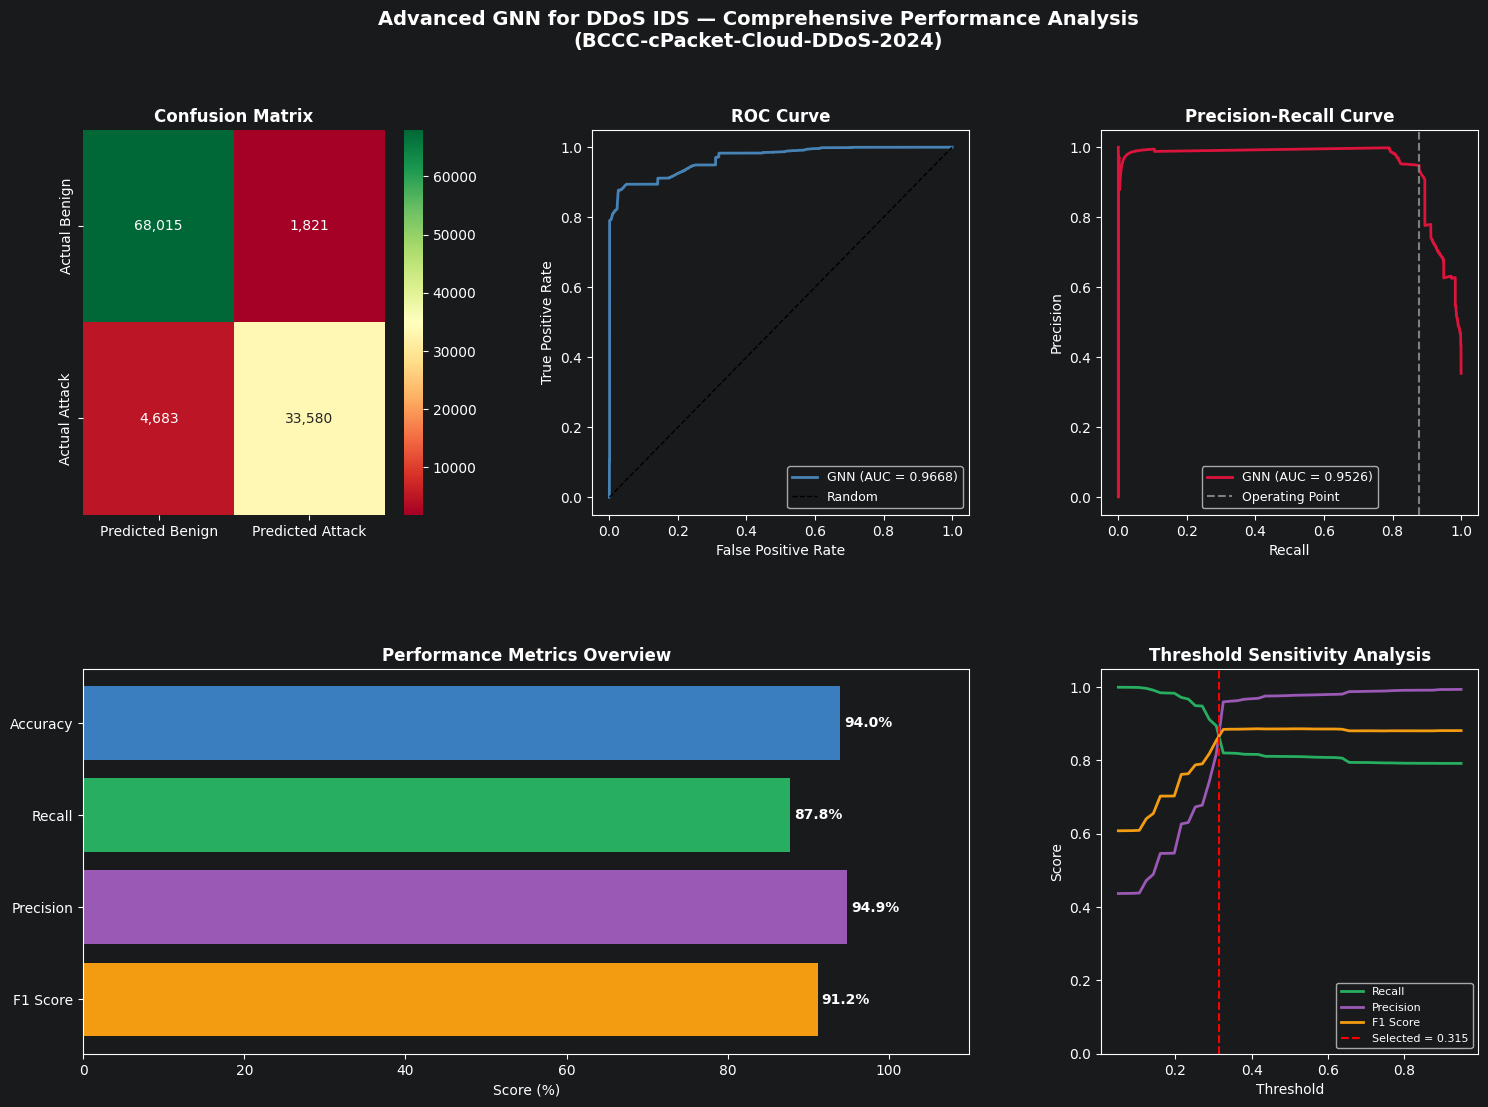

Figure saved: gnn_performance_analysis.png


In [19]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Advanced GNN for DDoS IDS — Comprehensive Performance Analysis\n(BCCC-cPacket-Cloud-DDoS-2024)',
             fontsize=14, fontweight='bold')

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

ax_cm = fig.add_subplot(gs[0, 0])
cm = np.array([[tn, fp], [fn, tp]])
sns.heatmap(cm, annot=True, fmt=',', cmap='RdYlGn',
            xticklabels=['Predicted Benign', 'Predicted Attack'],
            yticklabels=['Actual Benign', 'Actual Attack'],
            ax=ax_cm, cbar=True)
ax_cm.set_title('Confusion Matrix', fontweight='bold')

ax_roc = fig.add_subplot(gs[0, 1])
fpr_r, tpr_r, _ = roc_curve(test_true, test_probs)
roc_auc = auc(fpr_r, tpr_r)
ax_roc.plot(fpr_r, tpr_r, color='steelblue', lw=2,
            label=f'GNN (AUC = {roc_auc:.4f})')
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curve', fontweight='bold')
ax_roc.legend(fontsize=9)

ax_pr = fig.add_subplot(gs[0, 2])
pr_vals, rc_vals, _ = precision_recall_curve(test_true, test_probs)
pr_auc = auc(rc_vals, pr_vals)
ax_pr.plot(rc_vals, pr_vals, color='crimson', lw=2,
           label=f'GNN (AUC = {pr_auc:.4f})')
ax_pr.axvline(x=rec, color='gray', linestyle='--', lw=1.5, label='Operating Point')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curve', fontweight='bold')
ax_pr.legend(fontsize=9)

ax_met = fig.add_subplot(gs[1, 0:2])
metric_names  = ['F1 Score', 'Precision', 'Recall', 'Accuracy']
metric_values = [f1 * 100, prec * 100, rec * 100, acc]
bar_colors    = ['#F39C12', '#9B59B6', '#27AE60', '#3B7EBF']
bars_met = ax_met.barh(metric_names, metric_values, color=bar_colors)
for bar, val in zip(bars_met, metric_values):
    ax_met.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontweight='bold')
ax_met.set_xlim(0, 110)
ax_met.set_xlabel('Score (%)')
ax_met.set_title('Performance Metrics Overview', fontweight='bold')

ax_thr = fig.add_subplot(gs[1, 2])
thresholds_plot = np.linspace(0.05, 0.95, 50)
recalls_plot, precisions_plot, f1s_plot = [], [], []
for t in thresholds_plot:
    pred_t = (test_probs >= t).astype(int)
    recalls_plot.append(recall_score(test_true, pred_t, zero_division=0))
    precisions_plot.append(precision_score(test_true, pred_t, zero_division=0))
    f1s_plot.append(f1_score(test_true, pred_t, zero_division=0))

ax_thr.plot(thresholds_plot, recalls_plot,    color='#27AE60', lw=2, label='Recall')
ax_thr.plot(thresholds_plot, precisions_plot, color='#9B59B6', lw=2, label='Precision')
ax_thr.plot(thresholds_plot, f1s_plot,        color='#F39C12', lw=2, label='F1 Score')
ax_thr.axvline(x=best_thresh, color='red', linestyle='--', lw=1.5,
               label=f'Selected = {best_thresh:.3f}')
ax_thr.set_xlabel('Threshold')
ax_thr.set_ylabel('Score')
ax_thr.set_title('Threshold Sensitivity Analysis', fontweight='bold')
ax_thr.legend(fontsize=8)
ax_thr.set_ylim(0, 1.05)

plt.savefig('gnn_performance_analysis.png', dpi=150)
plt.show()
print('Figure saved: gnn_performance_analysis.png')

In [20]:
all_results = pd.DataFrame(results + [lp_result, gnn_result])

print('FULL COMPARISON TABLE — BCCC-cPacket-Cloud-DDoS-2024')
print('=' * 90)
print(all_results[['Model', 'ACC', 'FAR', 'UND', 'F1', 'Precision', 'Recall', 'Time']]
      .to_string(index=False))

best_acc = all_results.loc[all_results['ACC'].idxmax(), 'Model']
best_far = all_results.loc[all_results['FAR'].idxmin(), 'Model']
best_und = all_results.loc[all_results['UND'].idxmin(), 'Model']
best_f1  = all_results.loc[all_results['F1' ].idxmax(), 'Model']

print(f'\nBest Accuracy:         {best_acc}')
print(f'Lowest FAR:            {best_far}')
print(f'Lowest UND (critical): {best_und}')
print(f'Best F1 Score:         {best_f1}')


FULL COMPARISON TABLE — BCCC-cPacket-Cloud-DDoS-2024
              Model     ACC     FAR     UND     F1  Precision  Recall   Time
Logistic Regression 90.2025  4.7640 18.9844 0.8541     0.9031  0.8102   1.25
      Random Forest 96.2544  3.2175  4.7095 0.9474     0.9419  0.9529  29.78
        Naive Bayes 40.5314 90.4448  2.9323 0.5361     0.3703  0.9707   0.49
                KNN 96.3265  2.6118  5.6112 0.9479     0.9519  0.9439 105.55
      Decision Tree 95.9010  4.4662  3.4289 0.9434     0.9222  0.9657  23.33
  Label Propagation 96.2904  1.8028  7.1897 0.9466     0.9658  0.9281 119.65
  GNN (PyTorch GAT) 93.9833  2.6075 12.2390 0.9117     0.9486  0.8776 849.00

Best Accuracy:         KNN
Lowest FAR:            Label Propagation
Lowest UND (critical): Naive Bayes
Best F1 Score:         KNN


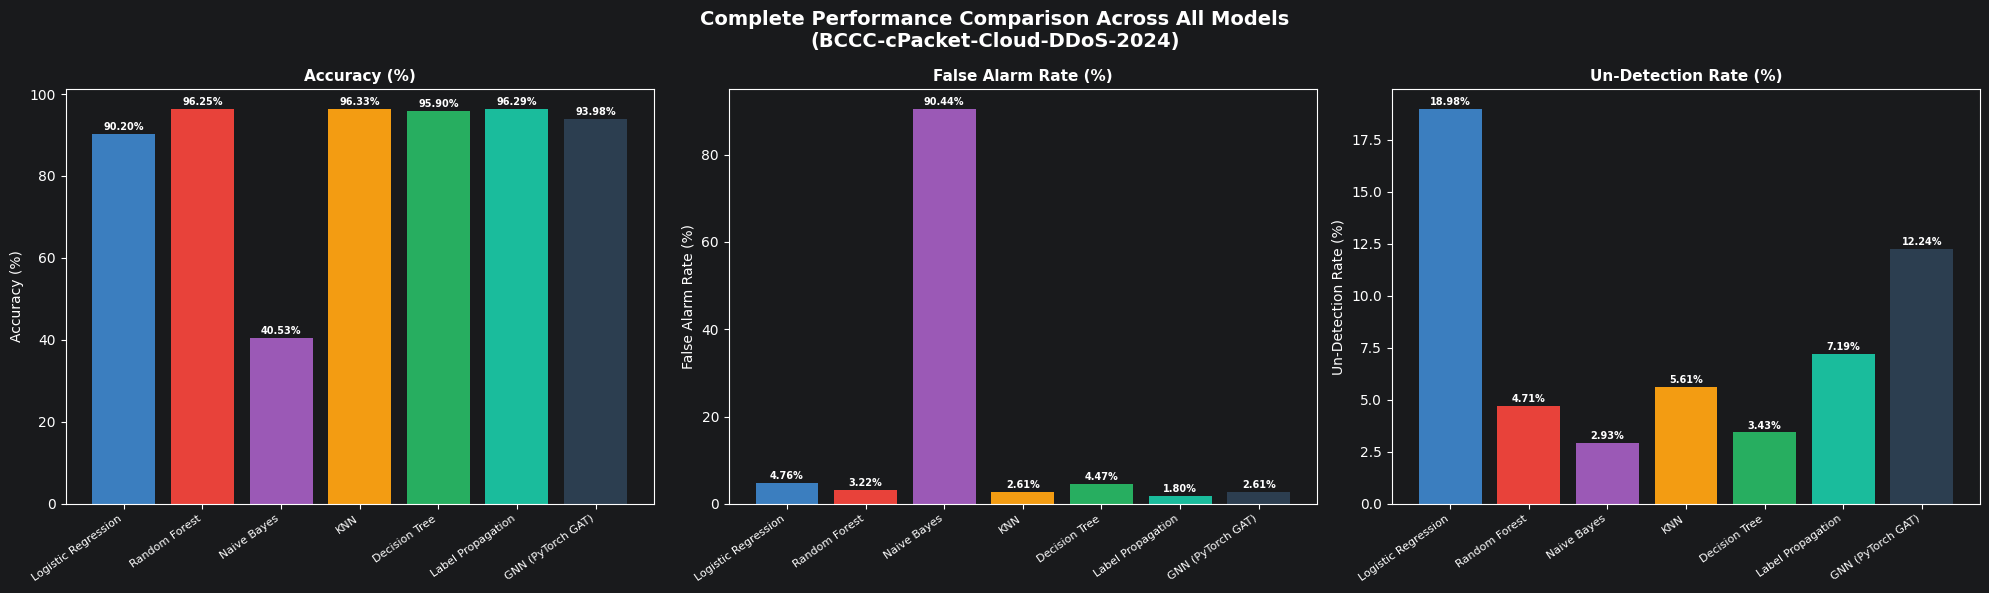

Figure saved: complete_comparison_all_models.png


In [21]:
all_colors = colors + ['#1ABC9C', '#2C3E50']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Complete Performance Comparison Across All Models\n(BCCC-cPacket-Cloud-DDoS-2024)',
             fontsize=14, fontweight='bold')

metrics = ['ACC', 'FAR', 'UND']
titles  = ['Accuracy (%)', 'False Alarm Rate (%)', 'Un-Detection Rate (%)']

for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.bar(all_results['Model'], all_results[metric],
                  color=all_colors[:len(all_results)])
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(title)
    ax.set_xticks(range(len(all_results)))
    ax.set_xticklabels(all_results['Model'], rotation=35, ha='right', fontsize=8)
    for bar, val in zip(bars, all_results[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(all_results[metric]) * 0.01,
                f'{val:.2f}%', ha='center', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.savefig('complete_comparison_all_models.png', dpi=150)
plt.show()
print('Figure saved: complete_comparison_all_models.png')